# The following analysis tries to find a kind seasonality 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import os

In [2]:
def compute_coefficients(zt, frequencies):
    T = len(zt)
    t = np.arange(T)
    
    omega_t = 2 * np.pi * frequencies.reshape(-1, 1) * t
    
    a_j = (2/T) * np.sum(zt.values * np.sin(omega_t), axis=1)
    b_j = (2/T) * np.sum(zt.values * np.cos(omega_t), axis=1)
    
    return a_j, b_j

In [3]:
def periodogram(zt):
    T = len(zt)
    num_freq = T//2 + 1
    frequencies = np.linspace(1/T, 0.1, num=num_freq, dtype=np.float32)
    
    a_j, b_j = compute_coefficients(zt, frequencies)
    periodogram = (T/2) * (np.square(a_j) + np.square(b_j))
    return dict(zip(frequencies, periodogram))

In [4]:
def create_two_plots_2(two_series_dictionary, x_lim_sup, x_lim_inf):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    axes = axes.flatten()
    for i, (key, value) in enumerate(two_series_dictionary.items()):
        ax_i = axes[i]
        periodogram_i = periodogram(value['glucose'])

        # ordenar por frecuencia para el plot
        sorted_by_freq = sorted(periodogram_i.items(), key=lambda kv: kv[0])
        x, y = zip(*sorted_by_freq)
        ax_i.plot(x, y, label='Periodogram')

        # obtener top 5 por potencia y trazar líneas verticales con colores distintos
        top_by_power = sorted(periodogram_i.items(), key=lambda kv: kv[1], reverse=True)
        top_n = min(5, len(top_by_power))
        top_freqs = [f for f, _ in top_by_power[:top_n]]

        cmap = plt.get_cmap('tab10')
        colors = [cmap(idx % cmap.N) for idx in range(top_n)]
        for k, (freq, color) in enumerate(zip(top_freqs, colors), start=1):
            ax_i.axvline(x=freq, color=color, linestyle='--', alpha=0.9, label=f'Top {k}: {freq:.6f}')

        ax_i.set(title=key)
        ax_i.set_xlim((x_lim_inf, x_lim_sup))
        ax_i.grid()
        ax_i.legend(loc='upper right', fontsize='small')
    plt.tight_layout()
    plt.show()

In [5]:
def plot_periodograms(keys, patients, xlim_inf, xlim_sup):
    num_patients = len(keys)
    print(num_patients)
    i = 0
    j = 1
    while j < num_patients:
        key_1 = keys[i]
        key_2 = keys[j]
        temp_dict = {key_1 : patients[key_1], key_2 : patients[key_2]}
        create_two_plots_2(temp_dict, xlim_sup, xlim_inf)     
        i += 2
        j = i + 1

Now we read and plot it

In [6]:
data_dir = '../Data/Preprocessed'
base_paths = os.listdir(data_dir)
full_paths = [os.path.join(data_dir, p) for p in base_paths]
full_paths

['../Data/Preprocessed/HUPA0004P.csv',
 '../Data/Preprocessed/HUPA0006P.csv',
 '../Data/Preprocessed/HUPA0007P.csv',
 '../Data/Preprocessed/HUPA0009P.csv',
 '../Data/Preprocessed/HUPA0005P.csv',
 '../Data/Preprocessed/HUPA0011P.csv',
 '../Data/Preprocessed/HUPA0003P.csv',
 '../Data/Preprocessed/HUPA0001P.csv',
 '../Data/Preprocessed/HUPA0010P.csv',
 '../Data/Preprocessed/HUPA0002P.csv',
 '../Data/Preprocessed/HUPA0014P.csv',
 '../Data/Preprocessed/HUPA0015P.csv',
 '../Data/Preprocessed/HUPA0016P.csv',
 '../Data/Preprocessed/HUPA0017P.csv',
 '../Data/Preprocessed/HUPA0018P.csv',
 '../Data/Preprocessed/HUPA0021P.csv',
 '../Data/Preprocessed/HUPA0020P.csv',
 '../Data/Preprocessed/HUPA0024P.csv',
 '../Data/Preprocessed/HUPA0019P.csv',
 '../Data/Preprocessed/HUPA0023P.csv',
 '../Data/Preprocessed/HUPA0022P.csv',
 '../Data/Preprocessed/HUPA0025P.csv',
 '../Data/Preprocessed/HUPA0028P.csv',
 '../Data/Preprocessed/HUPA0026P.csv',
 '../Data/Preprocessed/HUPA0027P.csv']

In [7]:
def extract_node_name(string):
    return string.split('/')[-1].split('.')[0]

def cast_to_time(df):
    df['time'] = pd.to_datetime(df['time'])
    return df

In [8]:
nodes_data = {extract_node_name(fp) : cast_to_time(pd.read_csv(fp, sep=';'))[['time', 'glucose']][:2290] for fp in full_paths}
nodes_keys = list(nodes_data.keys())

In [9]:
nodes_keys

['HUPA0004P',
 'HUPA0006P',
 'HUPA0007P',
 'HUPA0009P',
 'HUPA0005P',
 'HUPA0011P',
 'HUPA0003P',
 'HUPA0001P',
 'HUPA0010P',
 'HUPA0002P',
 'HUPA0014P',
 'HUPA0015P',
 'HUPA0016P',
 'HUPA0017P',
 'HUPA0018P',
 'HUPA0021P',
 'HUPA0020P',
 'HUPA0024P',
 'HUPA0019P',
 'HUPA0023P',
 'HUPA0022P',
 'HUPA0025P',
 'HUPA0028P',
 'HUPA0026P',
 'HUPA0027P']

In [10]:
nodes_data

{'HUPA0004P':                     time     glucose
 0    2018-07-09 15:30:00  161.000000
 1    2018-07-09 15:35:00  166.666667
 2    2018-07-09 15:40:00  172.333333
 3    2018-07-09 15:45:00  178.000000
 4    2018-07-09 15:50:00  192.666667
 ...                  ...         ...
 2285 2018-07-17 13:55:00  226.000000
 2286 2018-07-17 14:00:00  225.000000
 2287 2018-07-17 14:05:00  224.333333
 2288 2018-07-17 14:10:00  223.666667
 2289 2018-07-17 14:15:00  223.000000
 
 [2290 rows x 2 columns],
 'HUPA0006P':                     time     glucose
 0    2018-07-09 15:45:00  109.000000
 1    2018-07-09 15:50:00  107.666667
 2    2018-07-09 15:55:00  106.333333
 3    2018-07-09 16:00:00  105.000000
 4    2018-07-09 16:05:00  122.333333
 ...                  ...         ...
 2285 2018-07-17 14:10:00  101.333333
 2286 2018-07-17 14:15:00   97.000000
 2287 2018-07-17 14:20:00   92.666667
 2288 2018-07-17 14:25:00   88.333333
 2289 2018-07-17 14:30:00   84.000000
 
 [2290 rows x 2 columns],
 'HUPA

25


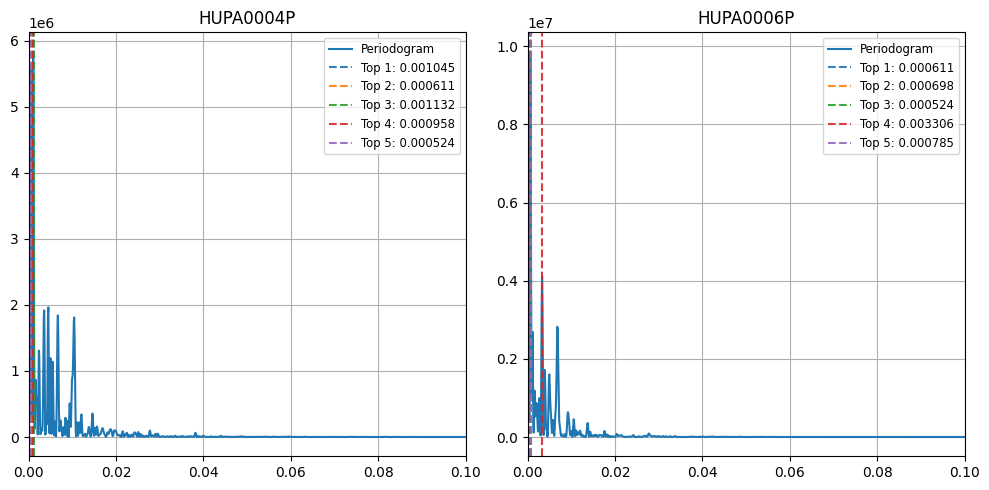

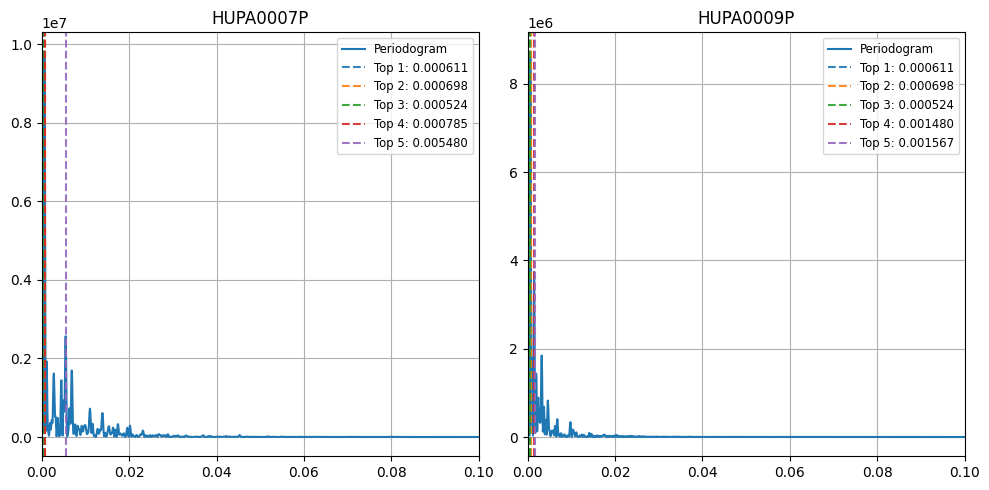

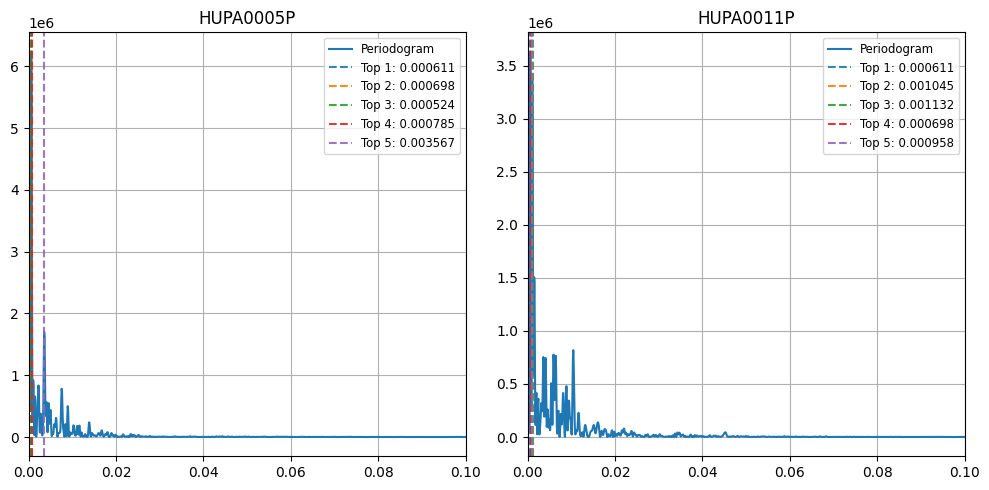

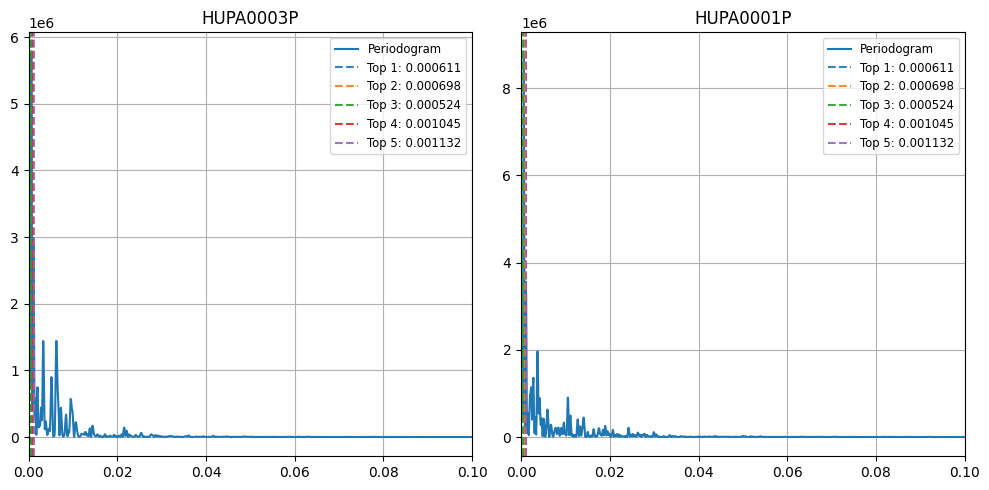

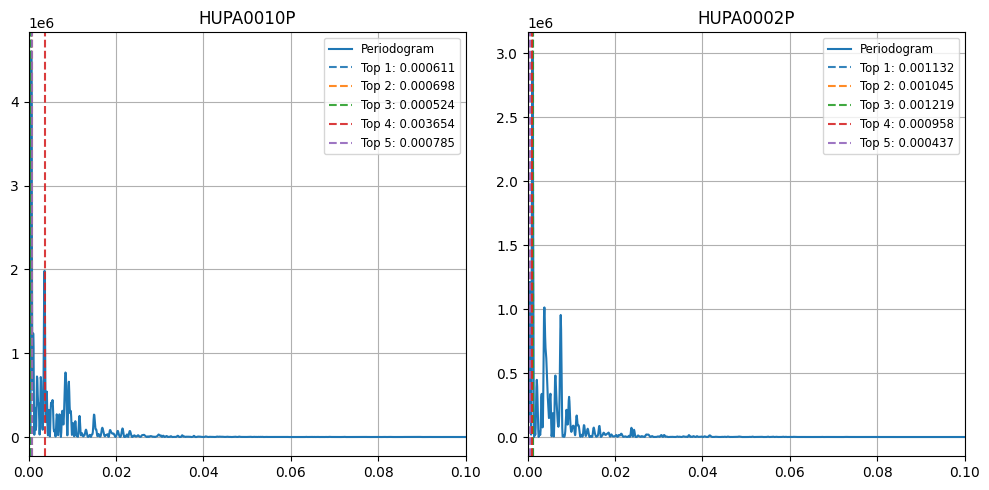

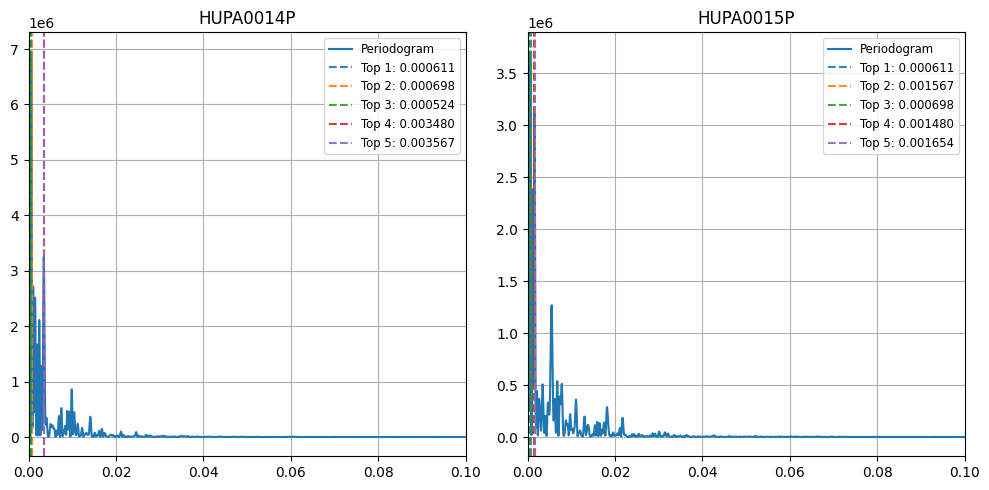

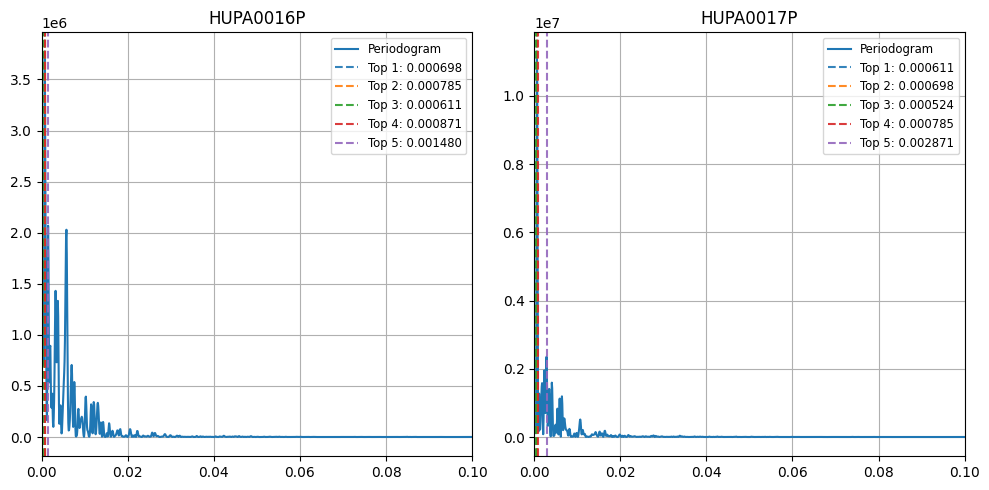

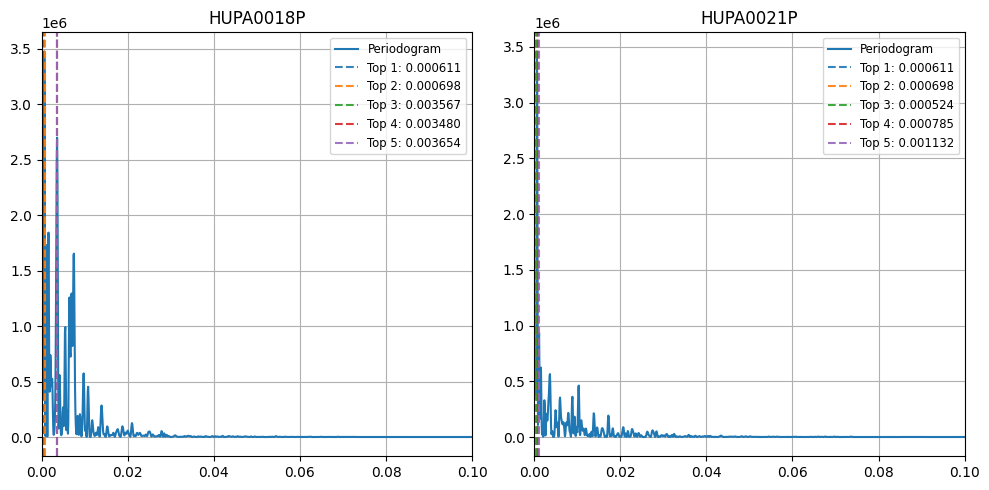

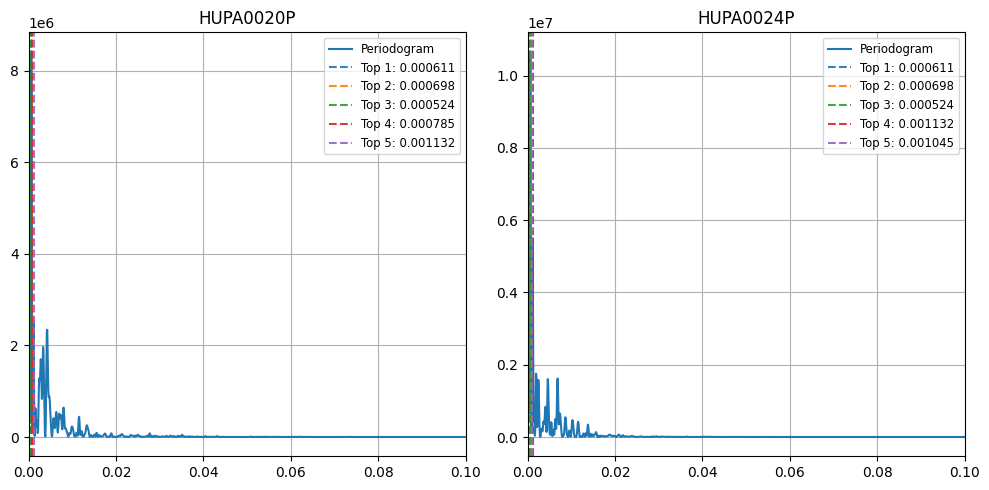

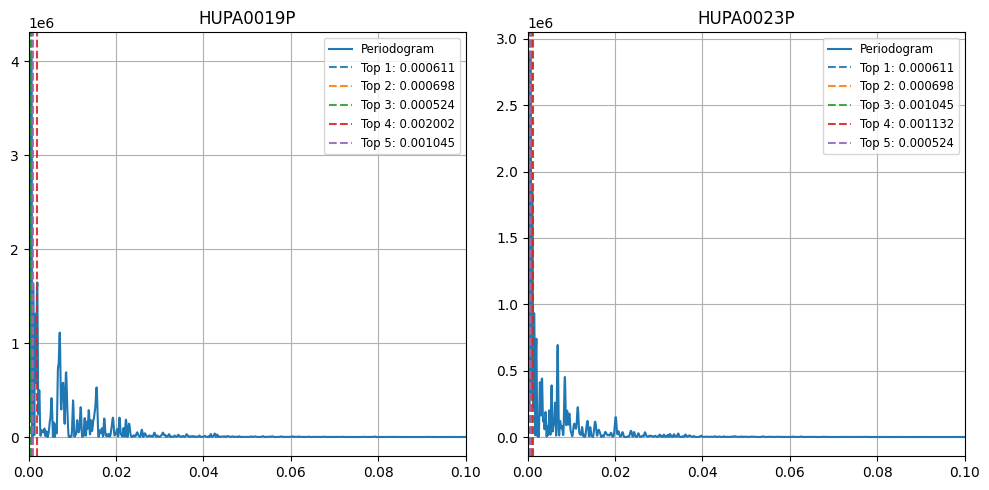

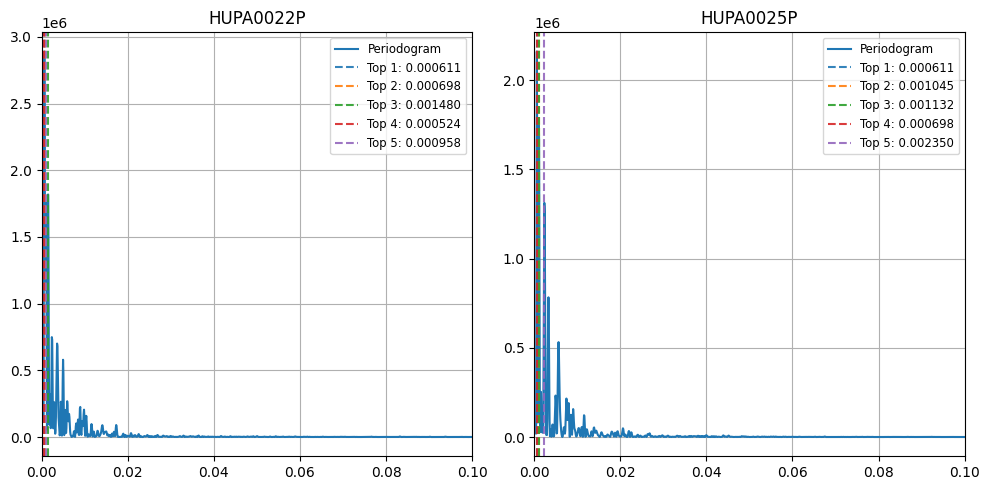

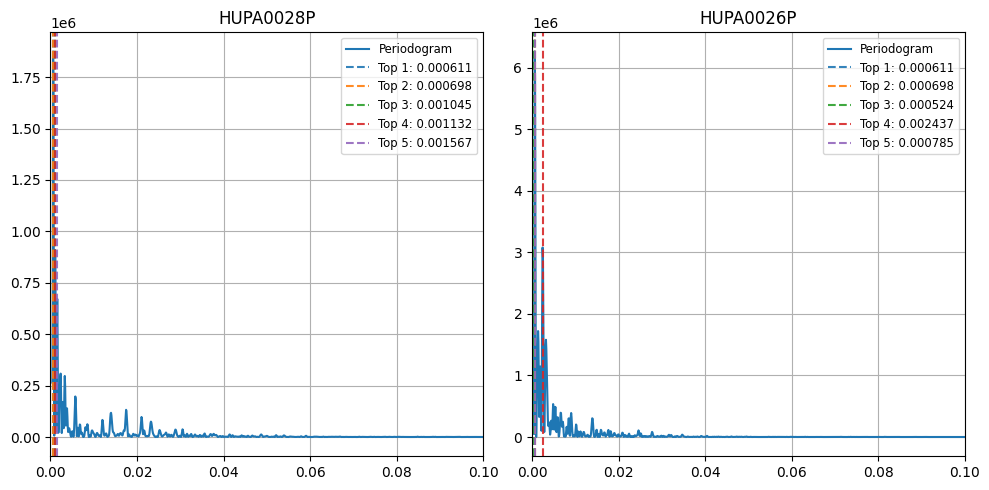

In [11]:
plot_periodograms(nodes_keys, nodes_data, 0, 0.1)

As we could see, seem like low frequency contributes more to variance, that's why we plot it using a shorter range

25


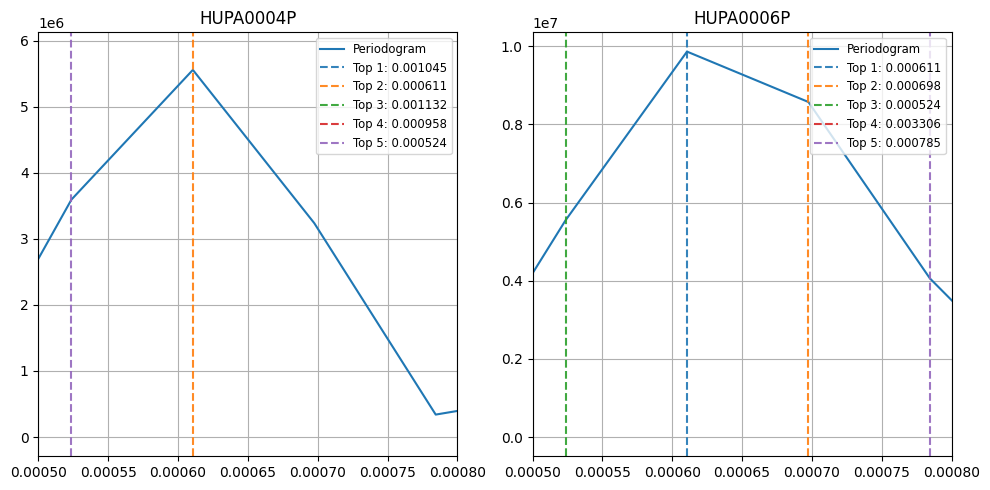

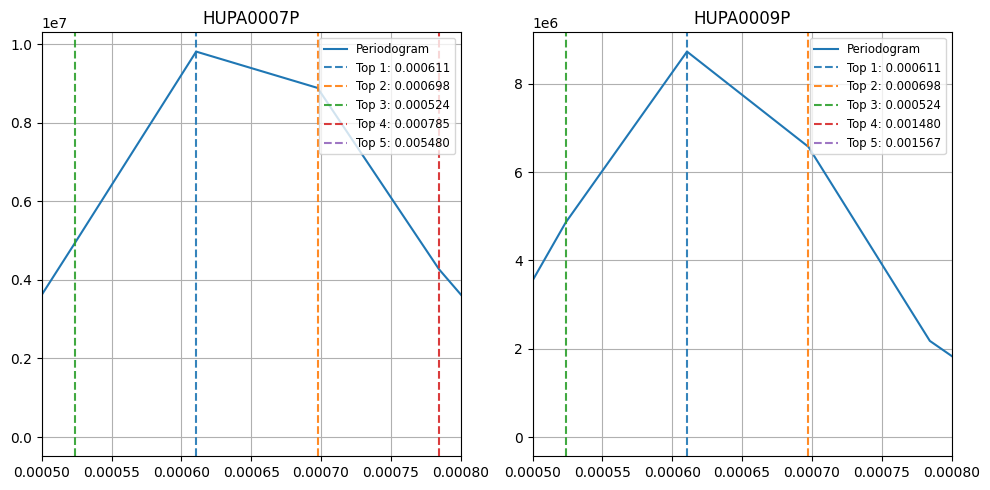

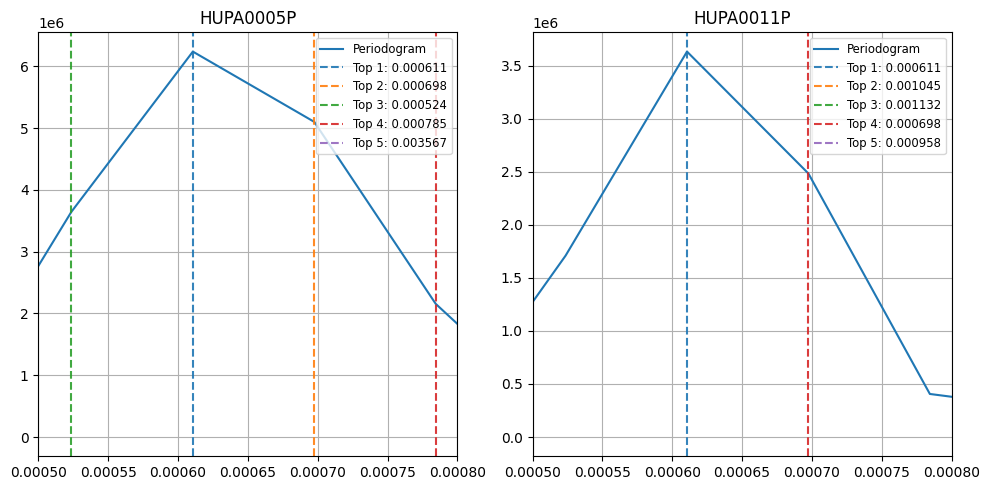

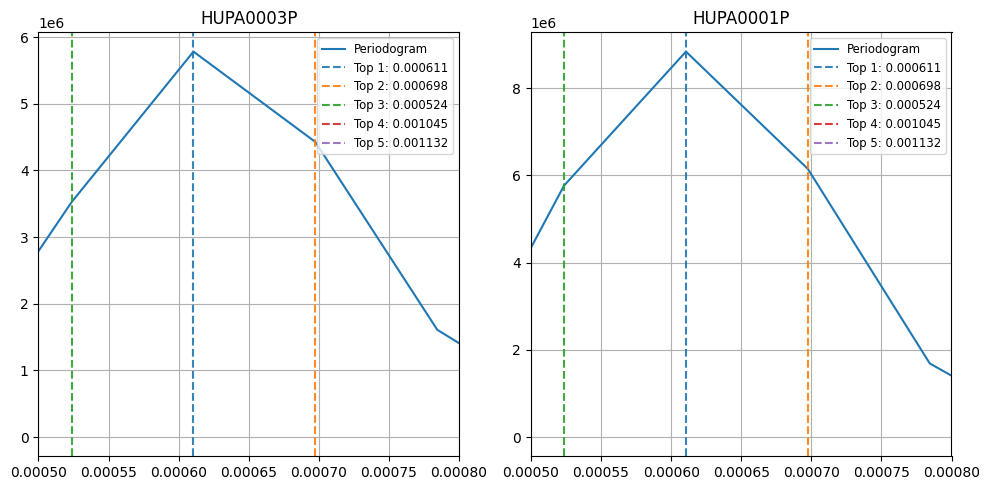

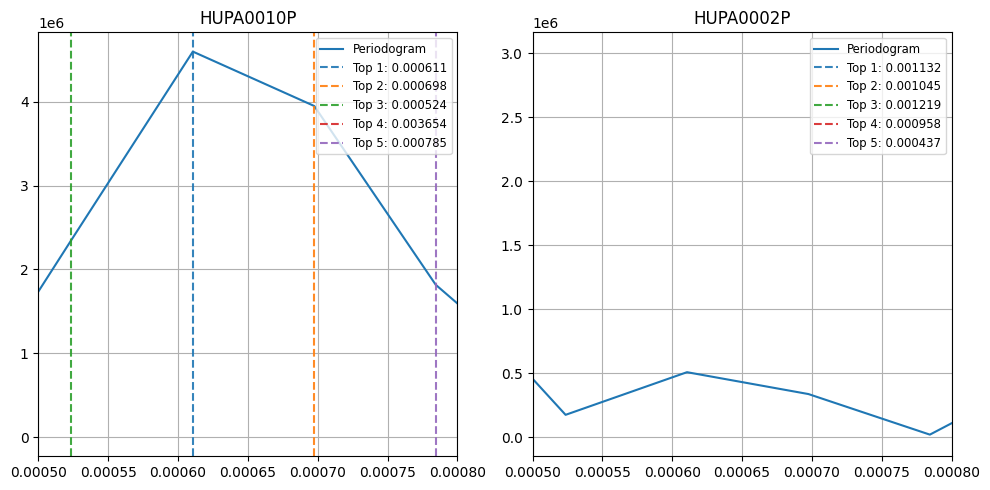

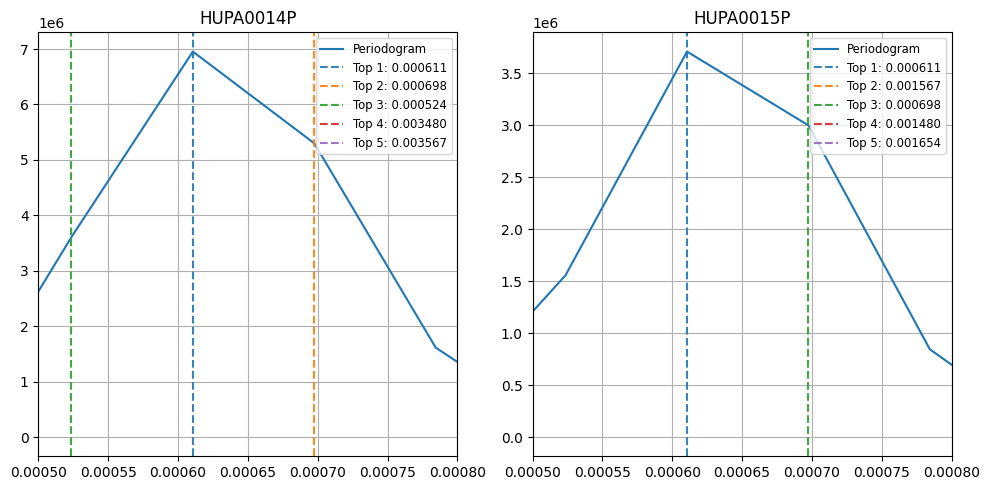

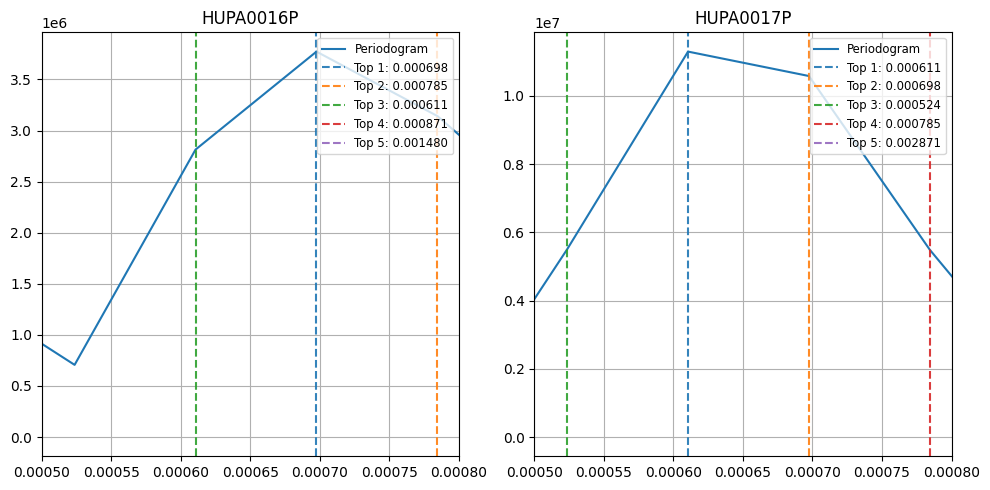

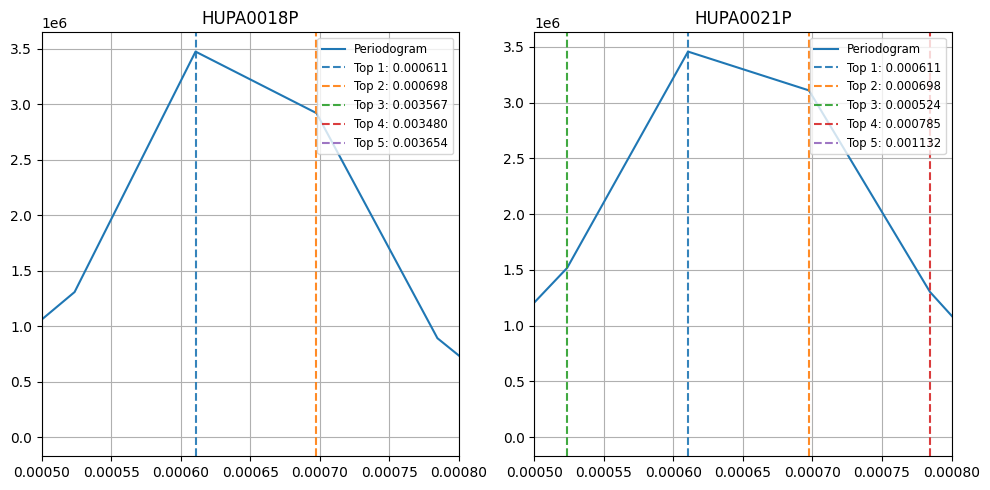

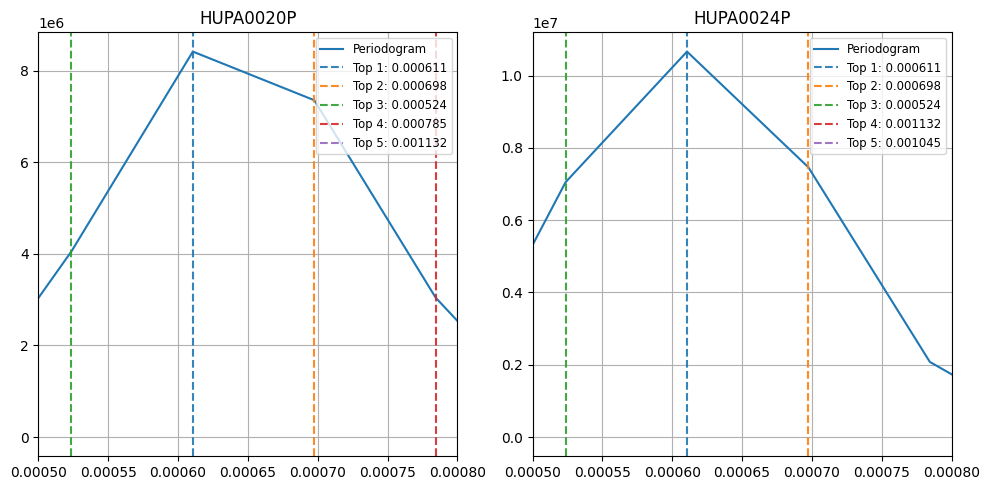

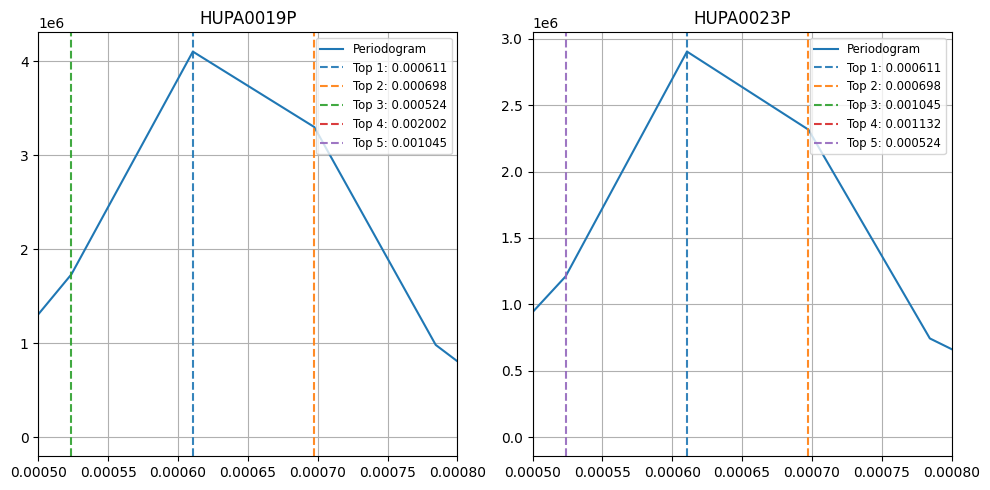

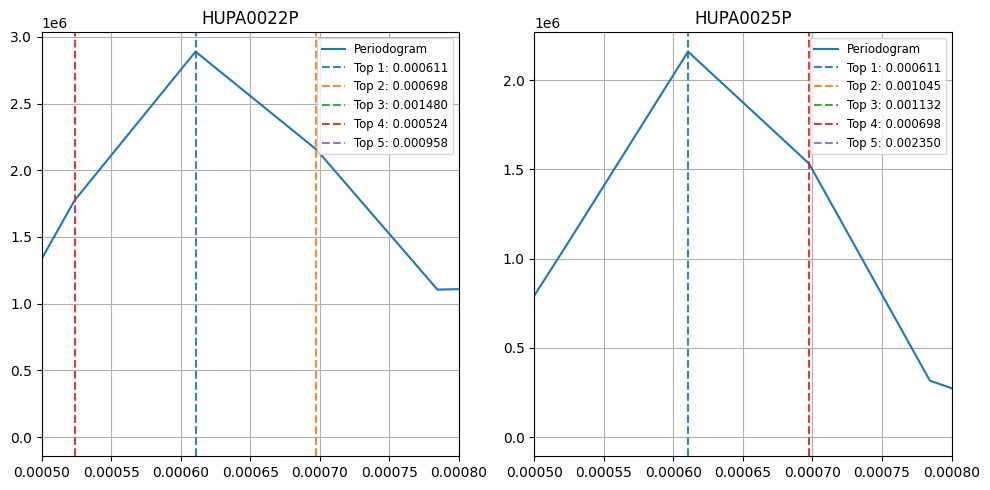

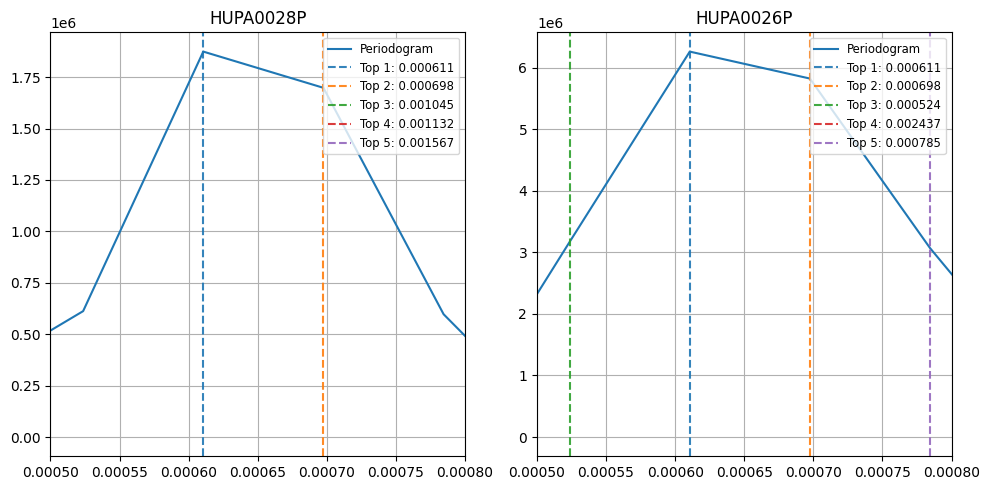

In [12]:
plot_periodograms(nodes_keys, nodes_data, xlim_inf=0.0005, xlim_sup=0.0008)

2


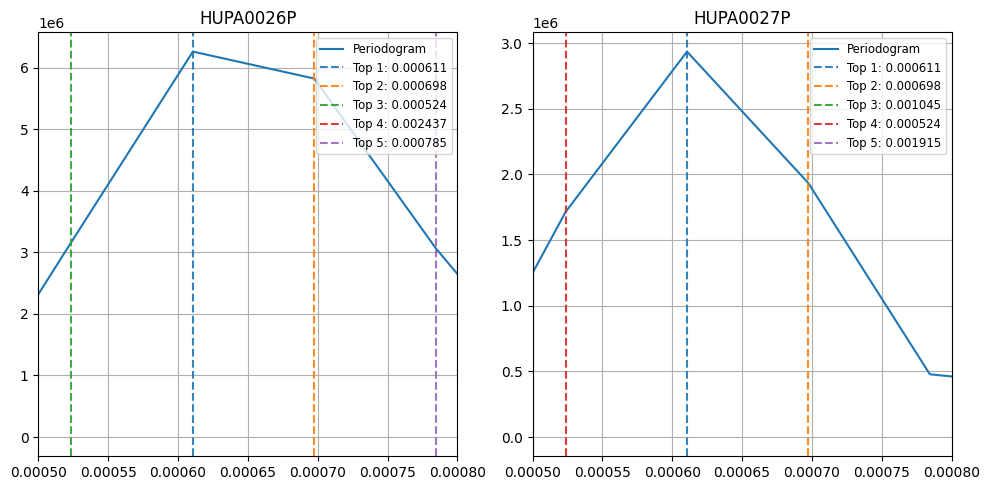

In [13]:
plot_periodograms(nodes_keys[-2:], nodes_data, xlim_inf=0.0005, xlim_sup=0.0008)

Even shorter ...

25


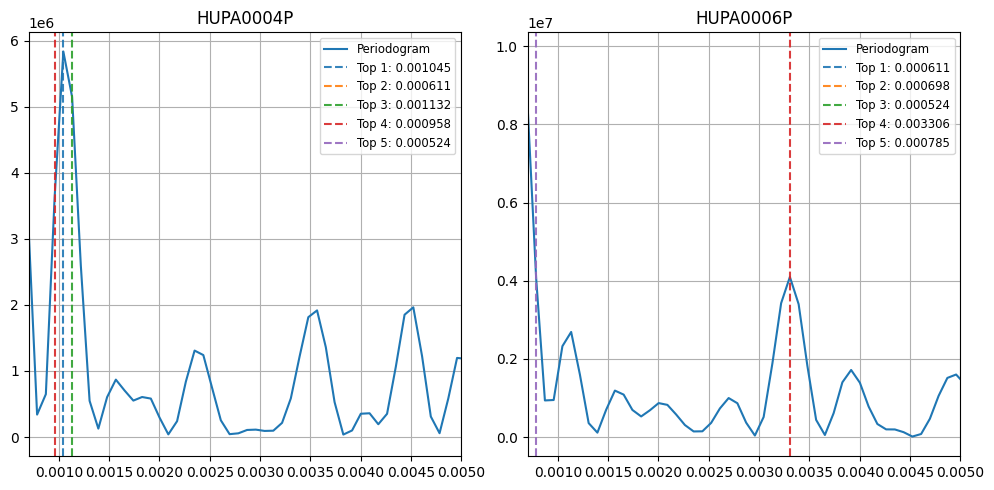

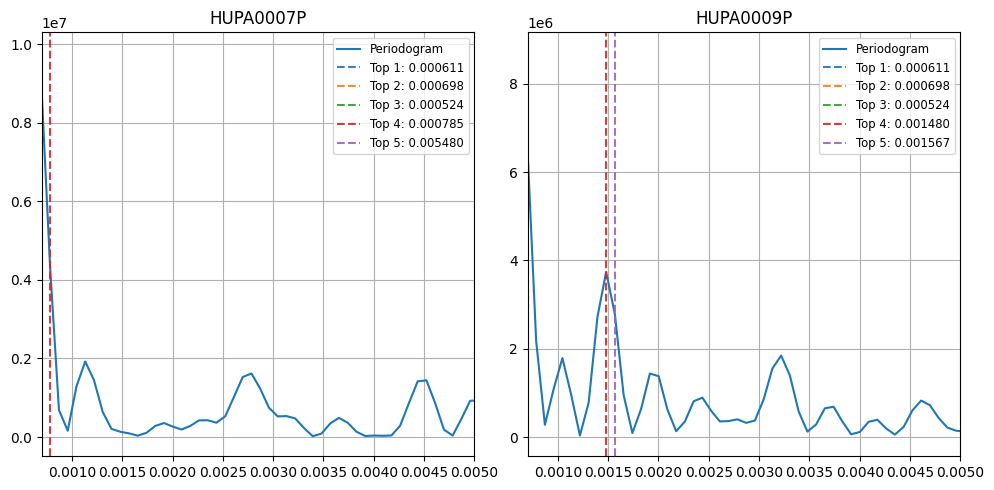

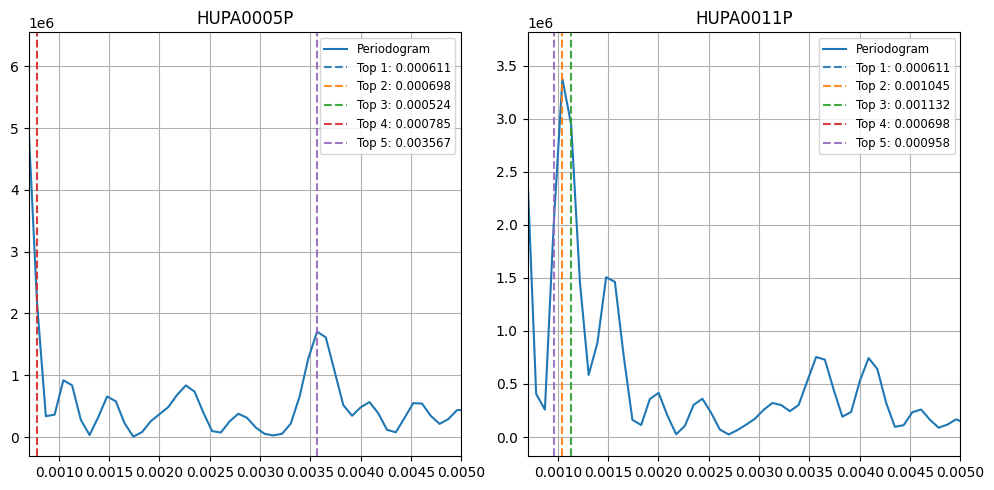

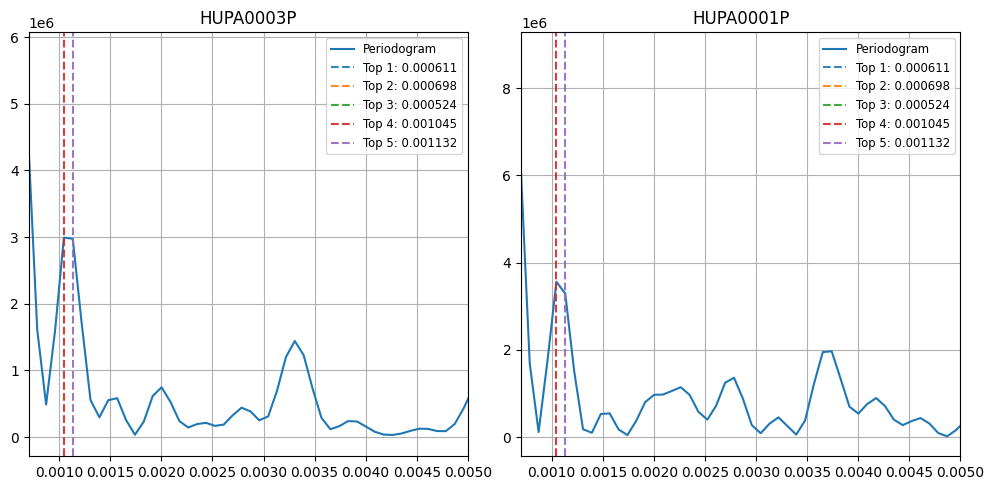

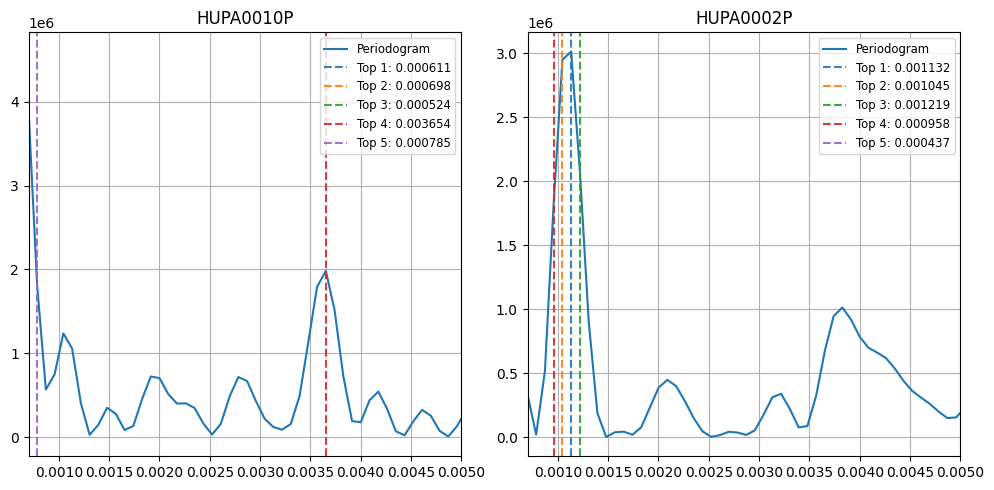

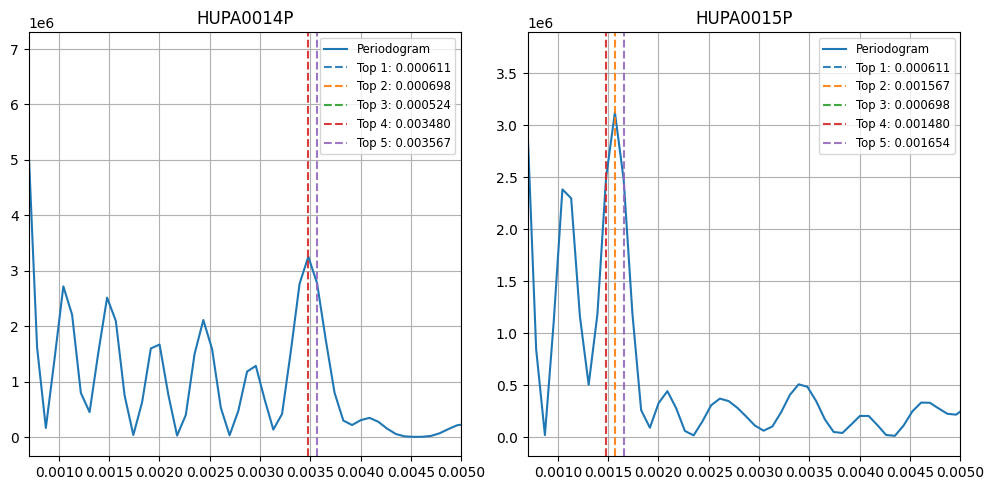

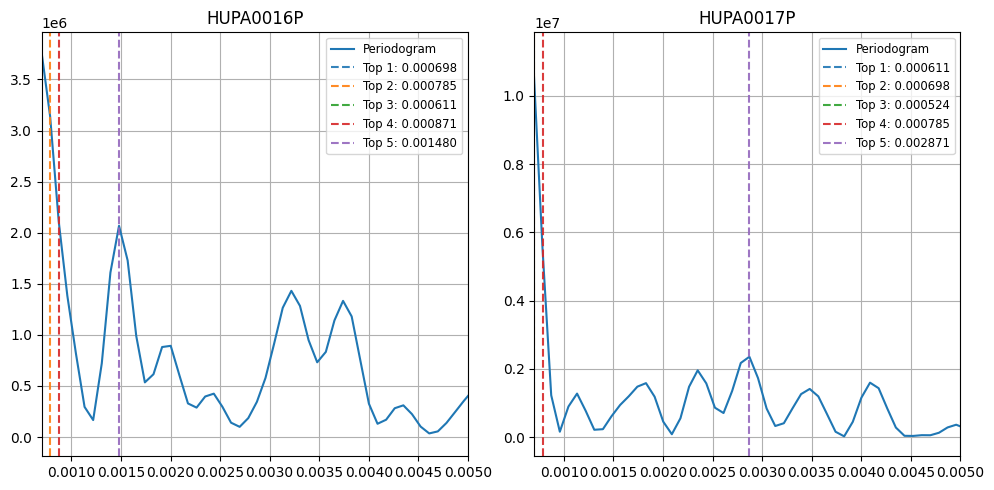

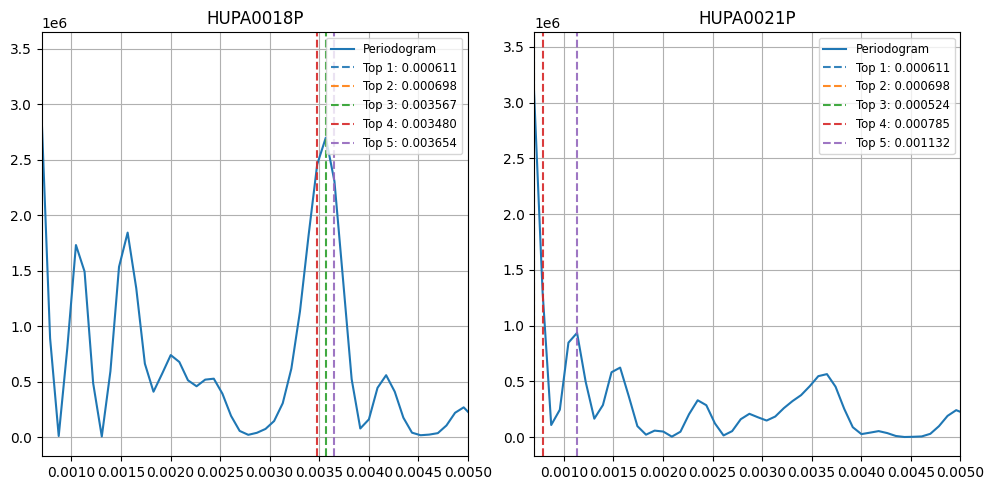

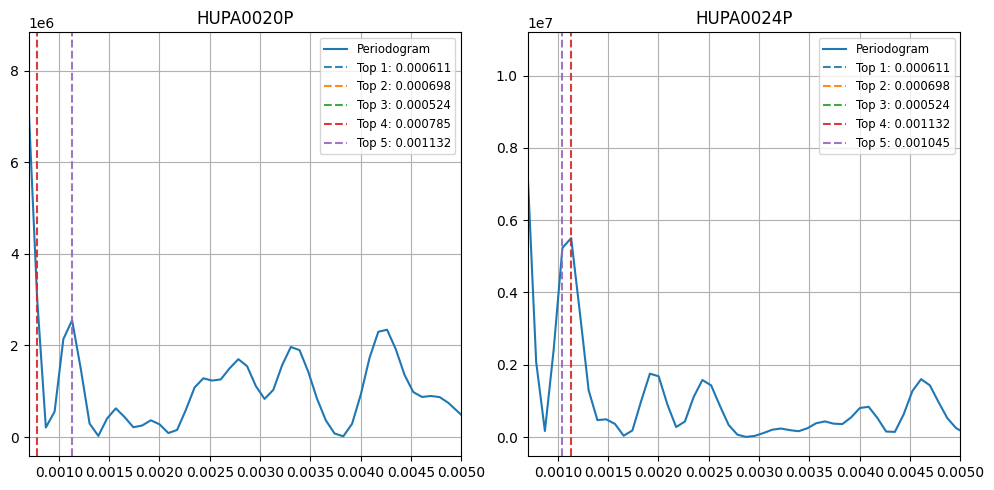

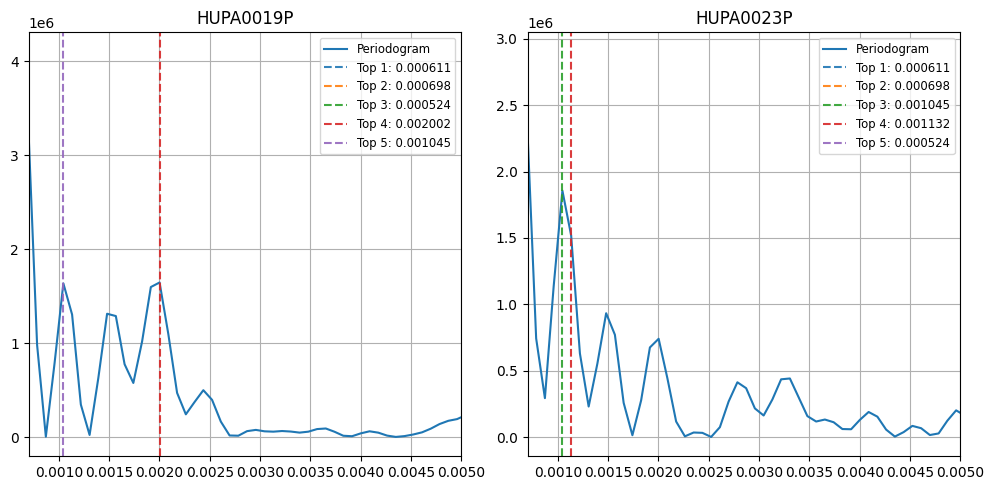

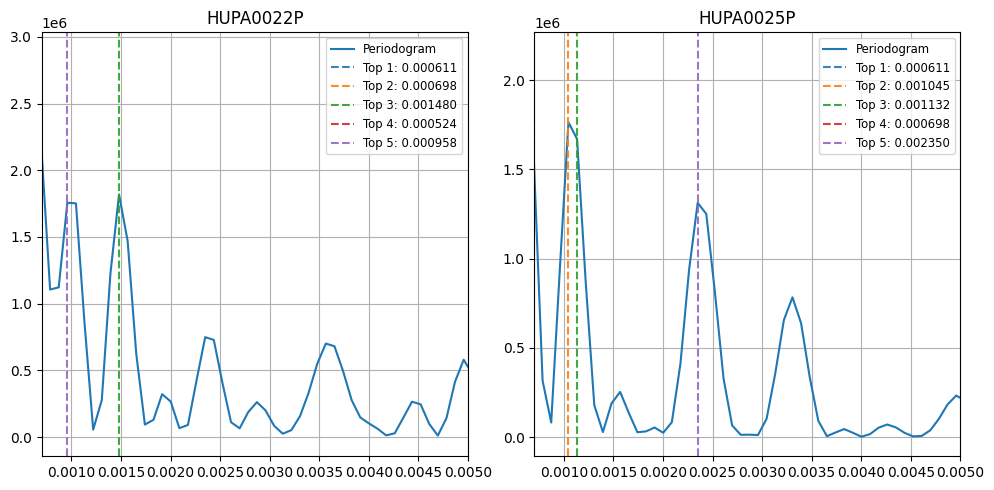

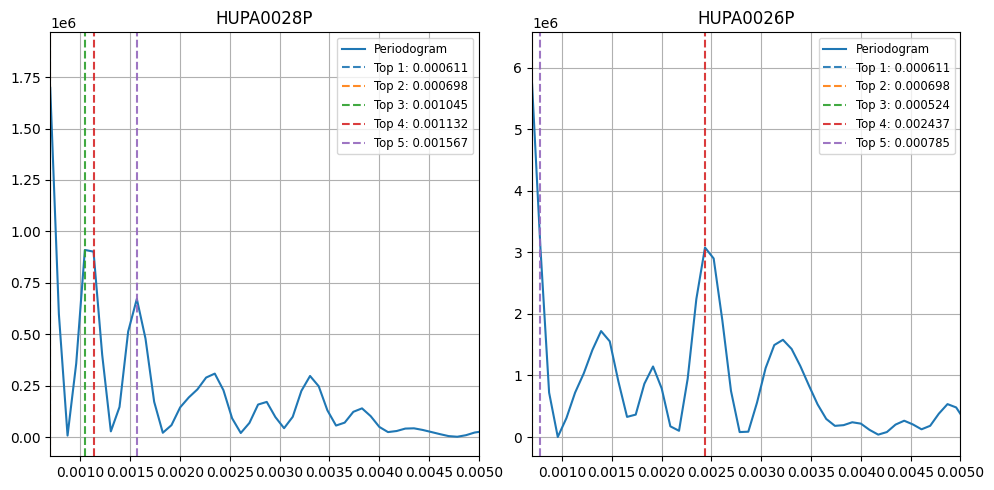

In [14]:
plot_periodograms(nodes_keys, nodes_data, xlim_inf=0.0007, xlim_sup=0.005)

As we could see, 1/041665=24.000960038, which makes sense for our target LMP !